In [1]:
import h5py
import numpy as np
from scipy.special import exp1
import xml.etree.ElementTree as ET

# --- Load data ---
f_ref_2 = h5py.File('../Theis/Inputs_less_Q/ref_2/Theis.h5', 'r')
elements = f_ref_2['elementsSpatial_Domain0'][:]
nodes = f_ref_2['nodesSpatial_Domain0'][:]
psi_0 = f_ref_2['pressure_head_t0'][:]

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

# --- Compute Voronoi volumes ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights = compute_voronoi_volumes(nodes, elements)

# --- Compute L2 error ---
def compute_L2_error(ph_num, ph_exact, weights):
    return (
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)),
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)) / 
        np.sqrt(np.sum(weights * (ph_exact)**2))
    )

# --- Theis head ---
def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

# --- Get time from XML ---
def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

# --- Loop over time steps ---
error_log = []

for key in f_ref_2:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_2:
            continue

        # Get time
        t_val = get_time_from_xml(f_ref_2[mesh_key][:])
        psi_num = f_ref_2[key][:]

        # Compute exact solution
        psi_exact = np.array([
            compute_theis_head(x, y, psi_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes)
        ])

        abs_l2, rel_l2 = compute_L2_error(psi_num, psi_exact, weights)
        error_log.append((t_val, abs_l2, rel_l2))

# --- Sort by time ---
error_log.sort(key=lambda x: x[0])

# --- Print all sorted results ---
for t_val, abs_l2, rel_l2 in error_log:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e}")



C:\Users\12254\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
C:\Users\12254\AppData\Local\Temp/ipykernel_9548/1451861803.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.50 s | Abs L2: 2.5182e-03 | Rel L2: 4.3724e-04
Time: 1.00 s | Abs L2: 4.1642e-03 | Rel L2: 7.2324e-04
Time: 1.50 s | Abs L2: 5.3818e-03 | Rel L2: 9.3494e-04
Time: 2.00 s | Abs L2: 6.5187e-03 | Rel L2: 1.1327e-03
Time: 2.50 s | Abs L2: 7.4953e-03 | Rel L2: 1.3026e-03
Time: 3.00 s | Abs L2: 8.3301e-03 | Rel L2: 1.4479e-03
Time: 3.50 s | Abs L2: 9.0614e-03 | Rel L2: 1.5752e-03
Time: 4.00 s | Abs L2: 9.7108e-03 | Rel L2: 1.6883e-03
Time: 4.50 s | Abs L2: 1.0294e-02 | Rel L2: 1.7898e-03
Time: 5.00 s | Abs L2: 1.0821e-02 | Rel L2: 1.8817e-03
Time: 5.50 s | Abs L2: 1.1256e-02 | Rel L2: 1.9576e-03
Time: 6.00 s | Abs L2: 1.1628e-02 | Rel L2: 2.0225e-03
Time: 6.50 s | Abs L2: 1.1954e-02 | Rel L2: 2.0792e-03
Time: 7.00 s | Abs L2: 1.2240e-02 | Rel L2: 2.1291e-03
Time: 7.50 s | Abs L2: 1.2491e-02 | Rel L2: 2.1731e-03
Time: 8.00 s | Abs L2: 1.2714e-02 | Rel L2: 2.2119e-03
Time: 8.50

In [2]:
# Save to reuse later
weights_ref_2 = weights
nodes_ref_2 = nodes
theis_ref_2_by_time = {
    t: np.array([compute_theis_head(x, y, psi_0[i], t) for i, (x, y, z) in enumerate(nodes)])
    for t, _, _ in error_log
}


C:\Users\12254\AppData\Local\Temp/ipykernel_9548/1451861803.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


In [3]:
import h5py
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator

# --- Load data from ref_0 ---
f_ref_0 = h5py.File('../Theis/Inputs_less_Q/ref_0/Theis.h5', 'r')
nodes_ref_0 = f_ref_0['nodesSpatial_Domain0'][:]

# Interpolation setup
tri = Delaunay(nodes_ref_0)
def interpolate_to_ref_2(source_values):
    interp = LinearNDInterpolator(tri, source_values)
    interpolated = interp(nodes_ref_2)
    valid = ~np.isnan(interpolated)
    return interpolated[valid], valid

# --- Loop through time steps ---
error_log_ref_0_to_ref_2 = []
for key in f_ref_0:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_0:
            continue

        t = get_time_from_xml(f_ref_0[mesh_key][:])
        psi_ref_0 = f_ref_0[key][:]

        # Interpolate
        psi_interp, valid_mask = interpolate_to_ref_2(psi_ref_0)
        psi_theis = theis_ref_2_by_time[t][valid_mask]
        weights_valid = weights_ref_2[valid_mask]

        # Error
        abs_l2, rel_l2 = compute_L2_error(psi_interp, psi_theis, weights_valid)
        error_log_ref_0_to_ref_2.append((t, abs_l2, rel_l2, np.sum(~valid_mask)))

# --- Output ---
error_log_ref_0_to_ref_2.sort()
for t, a, r, fallback in error_log_ref_0_to_ref_2:
    print(f"Time: {t:.2f} s | Abs L2: {a:.4e} | Rel L2: {r:.4e} | Fallbacks: {fallback}/{len(nodes_ref_2)}")


Time: 0.00 s | Abs L2: 5.2336e-16 | Rel L2: 9.2597e-17 | Fallbacks: 4131/56415
Time: 0.00 s | Abs L2: 5.2336e-16 | Rel L2: 9.2597e-17 | Fallbacks: 4131/56415
Time: 0.50 s | Abs L2: 1.4818e-03 | Rel L2: 2.6224e-04 | Fallbacks: 4131/56415
Time: 1.00 s | Abs L2: 2.4795e-03 | Rel L2: 4.3894e-04 | Fallbacks: 4131/56415
Time: 1.50 s | Abs L2: 3.1273e-03 | Rel L2: 5.5374e-04 | Fallbacks: 4131/56415
Time: 2.00 s | Abs L2: 3.8474e-03 | Rel L2: 6.8139e-04 | Fallbacks: 4131/56415
Time: 2.50 s | Abs L2: 4.6425e-03 | Rel L2: 8.2236e-04 | Fallbacks: 4131/56415
Time: 3.00 s | Abs L2: 5.3013e-03 | Rel L2: 9.3919e-04 | Fallbacks: 4131/56415
Time: 3.50 s | Abs L2: 5.8755e-03 | Rel L2: 1.0411e-03 | Fallbacks: 4131/56415
Time: 4.00 s | Abs L2: 6.3859e-03 | Rel L2: 1.1316e-03 | Fallbacks: 4131/56415
Time: 4.50 s | Abs L2: 6.8466e-03 | Rel L2: 1.2134e-03 | Fallbacks: 4131/56415
Time: 5.00 s | Abs L2: 7.2681e-03 | Rel L2: 1.2883e-03 | Fallbacks: 4131/56415
Time: 5.50 s | Abs L2: 7.4474e-03 | Rel L2: 1.3202e-

In [4]:
%%time
import h5py
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator

# --- Load data from ref_0 ---
f_ref_1 = h5py.File('../Theis/Inputs_less_Q/ref_1/Theis.h5', 'r')
nodes_ref_1 = f_ref_1['nodesSpatial_Domain0'][:]

# Interpolation setup
tri = Delaunay(nodes_ref_1)
def interpolate_to_ref_2(source_values):
    interp = LinearNDInterpolator(tri, source_values)
    interpolated = interp(nodes_ref_2)
    valid = ~np.isnan(interpolated)
    return interpolated[valid], valid

# --- Loop through time steps ---
error_log_ref_1_to_ref_2 = []
count= 0
for key in f_ref_1:
    
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_1:
            continue

        t = get_time_from_xml(f_ref_1[mesh_key][:])
        psi_ref_1 = f_ref_1[key][:]

        # Interpolate
        psi_interp, valid_mask = interpolate_to_ref_2(psi_ref_1)
        psi_theis = theis_ref_2_by_time[t][valid_mask]
        weights_valid = weights_ref_2[valid_mask]

        # Error
        abs_l2, rel_l2 = compute_L2_error(psi_interp, psi_theis, weights_valid)
        error_log_ref_1_to_ref_2.append((t, abs_l2, rel_l2, np.sum(~valid_mask)))
        count++
        print(count)

# --- Output ---
error_log_ref_1_to_ref_2.sort()
for t, a, r, fallback in error_log_ref_1_to_ref_2:
    print(f"Time: {t:.2f} s | Abs L2: {a:.4e} | Rel L2: {r:.4e} | Fallbacks: {fallback}/{len(nodes_ref_2)}")


Time: 0.00 s | Abs L2: 5.1991e-16 | Rel L2: 9.1130e-17 | Fallbacks: 2158/56415
Time: 0.00 s | Abs L2: 5.1991e-16 | Rel L2: 9.1130e-17 | Fallbacks: 2158/56415
Time: 0.50 s | Abs L2: 1.6270e-03 | Rel L2: 2.8527e-04 | Fallbacks: 2158/56415
Time: 1.00 s | Abs L2: 2.8896e-03 | Rel L2: 5.0677e-04 | Fallbacks: 2158/56415
Time: 1.50 s | Abs L2: 3.7584e-03 | Rel L2: 6.5929e-04 | Fallbacks: 2158/56415
Time: 2.00 s | Abs L2: 4.7017e-03 | Rel L2: 8.2494e-04 | Fallbacks: 2158/56415
Time: 2.50 s | Abs L2: 5.5472e-03 | Rel L2: 9.7345e-04 | Fallbacks: 2158/56415
Time: 3.00 s | Abs L2: 6.2453e-03 | Rel L2: 1.0961e-03 | Fallbacks: 2158/56415
Time: 3.50 s | Abs L2: 6.8438e-03 | Rel L2: 1.2013e-03 | Fallbacks: 2158/56415
Time: 4.00 s | Abs L2: 7.3644e-03 | Rel L2: 1.2929e-03 | Fallbacks: 2158/56415
Time: 4.50 s | Abs L2: 7.8232e-03 | Rel L2: 1.3736e-03 | Fallbacks: 2158/56415
Time: 5.00 s | Abs L2: 8.2316e-03 | Rel L2: 1.4454e-03 | Fallbacks: 2158/56415
Time: 5.50 s | Abs L2: 8.4861e-03 | Rel L2: 1.4903e-

In [8]:
%%time
import h5py
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator

# --- Load data from ref_0 ---
f_ref_neg_1 = h5py.File('../Theis/Inputs_less_Q/ref_neg_1/Theis.h5', 'r')
nodes_ref_neg_1 = f_ref_neg_1['nodesSpatial_Domain0'][:]

# Interpolation setup
tri = Delaunay(nodes_ref_neg_1)
def interpolate_to_ref_2(source_values):
    interp = LinearNDInterpolator(tri, source_values)
    interpolated = interp(nodes_ref_2)
    valid = ~np.isnan(interpolated)
    return interpolated[valid], valid

# --- Loop through time steps ---
error_log_ref_neg_1_to_ref_2 = []
count= 0
for key in f_ref_neg_1:
    
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_1:
            continue

        t = get_time_from_xml(f_ref_neg_1[mesh_key][:])
        psi_ref_neg_1 = f_ref_neg_1[key][:]

        # Interpolate
        psi_interp, valid_mask = interpolate_to_ref_2(psi_ref_neg_1)
        psi_theis = theis_ref_2_by_time[t][valid_mask]
        weights_valid = weights_ref_2[valid_mask]

        # Error
        abs_l2, rel_l2 = compute_L2_error(psi_interp, psi_theis, weights_valid)
        error_log_ref_neg_1_to_ref_2.append((t, abs_l2, rel_l2, np.sum(~valid_mask)))
        #count= count+1
        print(count)

# --- Output ---
error_log_ref_neg_1_to_ref_2.sort()
for t, a, r, fallback in error_log_ref_neg_1_to_ref_2:
    print(f"Time: {t:.2f} s | Abs L2: {a:.4e} | Rel L2: {r:.4e} | Fallbacks: {fallback}/{len(nodes_ref_2)}")


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
Time: 0.00 s | Abs L2: 5.3855e-16 | Rel L2: 9.5271e-17 | Fallbacks: 4104/56415
Time: 0.00 s | Abs L2: 5.3855e-16 | Rel L2: 9.5271e-17 | Fallbacks: 4104/56415
Time: 0.50 s | Abs L2: 1.9904e-03 | Rel L2: 3.5221e-04 | Fallbacks: 4104/56415
Time: 1.00 s | Abs L2: 2.2355e-03 | Rel L2: 3.9568e-04 | Fallbacks: 4104/56415
Time: 1.50 s | Abs L2: 2.2463e-03 | Rel L2: 3.9768e-04 | Fallbacks: 4104/56415
Time: 2.00 s | Abs L2: 2.0386e-03 | Rel L2: 3.6099e-04 | Fallbacks: 4104/56415
Time: 2.50 s | Abs L2: 2.0092e-03 | Rel L2: 3.5584e-04 | Fallbacks: 4104/56415
Time: 3.00 s | Abs L2: 2.2423e-03 | Rel L2:

In [10]:
# --- Load data from ref_0 ---
f_ref_neg_1_5 = h5py.File('../Theis/Inputs_less_Q/ref_neg_1_5/Theis.h5', 'r')


In [11]:
%%time
import h5py
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator

# --- Load data from ref_0 ---
f_ref_neg_1_5 = h5py.File('../Theis/Inputs_less_Q/ref_neg_1_5/Theis.h5', 'r')
nodes_ref_neg_1_5 = f_ref_neg_1_5['nodesSpatial_Domain0'][:]

# Interpolation setup
tri = Delaunay(nodes_ref_neg_1_5)
def interpolate_to_ref_2(source_values):
    interp = LinearNDInterpolator(tri, source_values)
    interpolated = interp(nodes_ref_2)
    valid = ~np.isnan(interpolated)
    return interpolated[valid], valid

# --- Loop through time steps ---
error_log_ref_neg_1_5_to_ref_2 = []
count= 0
for key in f_ref_neg_1_5:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_1_5:
            continue

        t = get_time_from_xml(f_ref_neg_1_5[mesh_key][:])
        psi_ref_neg_1_5 = f_ref_neg_1_5[key][:]

        # Interpolate
        psi_interp, valid_mask = interpolate_to_ref_2(psi_ref_neg_1_5)
        psi_theis = theis_ref_2_by_time[t][valid_mask]
        weights_valid = weights_ref_2[valid_mask]

        # Error
        abs_l2, rel_l2 = compute_L2_error(psi_interp, psi_theis, weights_valid)
        error_log_ref_neg_1_5_to_ref_2.append((t, abs_l2, rel_l2, np.sum(~valid_mask)))
        #count= count+1
        #print(count)

# --- Output ---
error_log_ref_neg_1_5_to_ref_2.sort()
for t, a, r, fallback in error_log_ref_neg_1_5_to_ref_2:
    print(f"Time: {t:.2f} s | Abs L2: {a:.4e} | Rel L2: {r:.4e} | Fallbacks: {fallback}/{len(nodes_ref_2)}")


Time: 0.00 s | Abs L2: 5.3783e-16 | Rel L2: 9.5408e-17 | Fallbacks: 4322/56415
Time: 0.00 s | Abs L2: 5.3783e-16 | Rel L2: 9.5408e-17 | Fallbacks: 4322/56415
Time: 0.50 s | Abs L2: 2.2073e-03 | Rel L2: 3.9166e-04 | Fallbacks: 4322/56415
Time: 1.00 s | Abs L2: 2.2884e-03 | Rel L2: 4.0617e-04 | Fallbacks: 4322/56415
Time: 1.50 s | Abs L2: 2.1402e-03 | Rel L2: 3.7995e-04 | Fallbacks: 4322/56415
Time: 2.00 s | Abs L2: 1.9880e-03 | Rel L2: 3.5301e-04 | Fallbacks: 4322/56415
Time: 2.50 s | Abs L2: 2.2059e-03 | Rel L2: 3.9178e-04 | Fallbacks: 4322/56415
Time: 3.00 s | Abs L2: 2.6709e-03 | Rel L2: 4.7443e-04 | Fallbacks: 4322/56415
Time: 3.50 s | Abs L2: 3.1738e-03 | Rel L2: 5.6384e-04 | Fallbacks: 4322/56415
Time: 4.00 s | Abs L2: 3.6693e-03 | Rel L2: 6.5195e-04 | Fallbacks: 4322/56415
Time: 4.50 s | Abs L2: 4.1450e-03 | Rel L2: 7.3655e-04 | Fallbacks: 4322/56415
Time: 5.00 s | Abs L2: 4.5826e-03 | Rel L2: 8.1440e-04 | Fallbacks: 4322/56415
Time: 5.50 s | Abs L2: 4.5054e-03 | Rel L2: 8.0075e-

In [9]:
%%time
import h5py
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator

# --- Load data from ref_0 ---
f_ref_neg_2 = h5py.File('../Theis/Inputs_less_Q/ref_neg_2/Theis.h5', 'r')
nodes_ref_neg_2 = f_ref_neg_2['nodesSpatial_Domain0'][:]

# Interpolation setup
tri = Delaunay(nodes_ref_neg_2)
def interpolate_to_ref_2(source_values):
    interp = LinearNDInterpolator(tri, source_values)
    interpolated = interp(nodes_ref_2)
    valid = ~np.isnan(interpolated)
    return interpolated[valid], valid

# --- Loop through time steps ---
error_log_ref_neg_2_to_ref_2 = []
count= 0
for key in f_ref_neg_2:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_2:
            continue

        t = get_time_from_xml(f_ref_neg_2[mesh_key][:])
        psi_ref_neg_2 = f_ref_neg_2[key][:]

        # Interpolate
        psi_interp, valid_mask = interpolate_to_ref_2(psi_ref_neg_2)
        psi_theis = theis_ref_2_by_time[t][valid_mask]
        weights_valid = weights_ref_2[valid_mask]

        # Error
        abs_l2, rel_l2 = compute_L2_error(psi_interp, psi_theis, weights_valid)
        error_log_ref_neg_2_to_ref_2.append((t, abs_l2, rel_l2, np.sum(~valid_mask)))
        #count= count+1
        #print(count)

# --- Output ---
error_log_ref_neg_2_to_ref_2.sort()
for t, a, r, fallback in error_log_ref_neg_2_to_ref_2:
    print(f"Time: {t:.2f} s | Abs L2: {a:.4e} | Rel L2: {r:.4e} | Fallbacks: {fallback}/{len(nodes_ref_2)}")


Time: 0.00 s | Abs L2: 4.4069e-16 | Rel L2: 8.0614e-17 | Fallbacks: 6920/56415
Time: 0.00 s | Abs L2: 4.4069e-16 | Rel L2: 8.0614e-17 | Fallbacks: 6920/56415
Time: 0.50 s | Abs L2: 6.1251e-03 | Rel L2: 1.1208e-03 | Fallbacks: 6920/56415
Time: 1.00 s | Abs L2: 6.4220e-03 | Rel L2: 1.1754e-03 | Fallbacks: 6920/56415
Time: 1.50 s | Abs L2: 6.3073e-03 | Rel L2: 1.1547e-03 | Fallbacks: 6920/56415
Time: 2.00 s | Abs L2: 5.9713e-03 | Rel L2: 1.0934e-03 | Fallbacks: 6920/56415
Time: 2.50 s | Abs L2: 5.2419e-03 | Rel L2: 9.6004e-04 | Fallbacks: 6920/56415
Time: 3.00 s | Abs L2: 4.9803e-03 | Rel L2: 9.1228e-04 | Fallbacks: 6920/56415
Time: 3.50 s | Abs L2: 4.7807e-03 | Rel L2: 8.7584e-04 | Fallbacks: 6920/56415
Time: 4.00 s | Abs L2: 4.6374e-03 | Rel L2: 8.4969e-04 | Fallbacks: 6920/56415
Time: 4.50 s | Abs L2: 4.5460e-03 | Rel L2: 8.3304e-04 | Fallbacks: 6920/56415
Time: 5.00 s | Abs L2: 4.5001e-03 | Rel L2: 8.2471e-04 | Fallbacks: 6920/56415
Time: 5.50 s | Abs L2: 4.5011e-03 | Rel L2: 8.2498e-

In [12]:
import numpy as np

def compute_convergence_rates(error_logs):
    """
    Computes convergence rates (absolute and relative L2 errors) between mesh levels.

    Parameters:
        error_logs (list of tuples): Each tuple is (label, h_e, error_log)
            where error_log is a list of (time, abs_l2, rel_l2).

    Returns:
        rates (list of tuples): Each tuple is (time, h1, h2, abs_rate, rel_rate)
    """
    # Sort from coarse to fine (descending h)
    error_logs.sort(key=lambda x: x[1], reverse=True)

    convergence_rates = []

    for i in range(len(error_logs) - 1):
        label1, h1, data1 = error_logs[i]
        label2, h2, data2 = error_logs[i + 1]

        for (t1, abs1, rel1), (t2, abs2, rel2) in zip(data1, data2):
            if not np.isclose(t1, t2):
                raise ValueError(f"Time mismatch between levels: {t1} != {t2}")
            abs_rate = np.log(abs2 / abs1) / np.log(h2 / h1)
            rel_rate = np.log(rel2 / rel1) / np.log(h2 / h1)
            convergence_rates.append((t1, h1, h2, abs_rate, rel_rate))

    return convergence_rates


In [15]:
def compute_convergence_rates(error_logs):
    """
    Computes convergence rates (absolute and relative L2 errors) between mesh levels.

    Parameters:
        error_logs (list of tuples): Each tuple is (label, h_e, error_log)
            where error_log is a list of (time, abs_l2, rel_l2, fallback_count).

    Returns:
        rates (list of tuples): Each tuple is (time, h1, h2, abs_rate, rel_rate)
    """
    # Sort from coarse to fine (descending h)
    error_logs.sort(key=lambda x: x[1], reverse=True)

    convergence_rates = []

    for i in range(len(error_logs) - 1):
        label1, h1, data1 = error_logs[i]
        label2, h2, data2 = error_logs[i + 1]

        for d1, d2 in zip(data1, data2):
            t1, abs1, rel1, *_ = d1
            t2, abs2, rel2, *_ = d2
            if not np.isclose(t1, t2):
                raise ValueError(f"Time mismatch between levels: {t1} != {t2}")
            abs_rate = np.log(abs2 / abs1) / np.log(h2 / h1)
            rel_rate = np.log(rel2 / rel1) / np.log(h2 / h1)
            convergence_rates.append((t1, h1, h2, abs_rate, rel_rate))

    return convergence_rates


In [16]:
# Example usage assuming the logs are named and loaded
error_logs = [
    ("error_log_ref_neg_2_to_ref_2", 1.6, error_log_ref_neg_2_to_ref_2),
    ("error_log_ref_neg_1_5_to_ref_2", 1.2, error_log_ref_neg_1_5_to_ref_2),
    #("error_log_ref_neg_1_to_ref_2", 0.8, error_log_ref_neg_1_to_ref_2),
]

rates = compute_convergence_rates(error_logs)

# Print result
print("Time (s) | h1 -> h2 | Abs Rate | Rel Rate")
print("------------------------------------------")
for t, h1, h2, abs_r, rel_r in rates:
    print(f"{t:8.2f} | {h1:.1f}->{h2:.1f} | {abs_r:8.4f} | {rel_r:8.4f}")


Time (s) | h1 -> h2 | Abs Rate | Rel Rate
------------------------------------------
    0.00 | 1.6->1.2 |  -0.6924 |  -0.5857
    0.00 | 1.6->1.2 |  -0.6924 |  -0.5857
    0.50 | 1.6->1.2 |   3.5478 |   3.6546
    1.00 | 1.6->1.2 |   3.5868 |   3.6937
    1.50 | 1.6->1.2 |   3.7570 |   3.8639
    2.00 | 1.6->1.2 |   3.8231 |   3.9300
    2.50 | 1.6->1.2 |   3.0086 |   3.1155
    3.00 | 1.6->1.2 |   2.1659 |   2.2728
    3.50 | 1.6->1.2 |   1.4240 |   1.5309
    4.00 | 1.6->1.2 |   0.8139 |   0.9209
    4.50 | 1.6->1.2 |   0.3210 |   0.4279
    5.00 | 1.6->1.2 |  -0.0632 |   0.0437
    5.50 | 1.6->1.2 |  -0.0033 |   0.1036
    6.00 | 1.6->1.2 |   0.1727 |   0.2797
    6.50 | 1.6->1.2 |   0.3584 |   0.4654
    7.00 | 1.6->1.2 |   0.5381 |   0.6451
    7.50 | 1.6->1.2 |   0.7065 |   0.8134
    8.00 | 1.6->1.2 |   0.8621 |   0.9691
    8.50 | 1.6->1.2 |   1.0053 |   1.1123
    9.00 | 1.6->1.2 |   1.1369 |   1.2438
    9.50 | 1.6->1.2 |   1.2578 |   1.3647
   10.00 | 1.6->1.2 |   1.3690 | 

In [17]:
# Example usage assuming the logs are named and loaded
error_logs = [
    ("error_log_ref_neg_1_5_to_ref_2", 1.2, error_log_ref_neg_2_to_ref_2),
    ("error_log_ref_neg_1_to_ref_2", 0.8, error_log_ref_neg_1_5_to_ref_2),
    #("error_log_ref_neg_1_to_ref_2", 0.8, error_log_ref_neg_1_to_ref_2),
]

rates = compute_convergence_rates(error_logs)

# Print result
print("Time (s) | h1 -> h2 | Abs Rate | Rel Rate")
print("------------------------------------------")
for t, h1, h2, abs_r, rel_r in rates:
    print(f"{t:8.2f} | {h1:.1f}->{h2:.1f} | {abs_r:8.4f} | {rel_r:8.4f}")


Time (s) | h1 -> h2 | Abs Rate | Rel Rate
------------------------------------------
    0.00 | 1.2->0.8 |  -0.4913 |  -0.4156
    0.00 | 1.2->0.8 |  -0.4913 |  -0.4156
    0.50 | 1.2->0.8 |   2.5172 |   2.5930
    1.00 | 1.2->0.8 |   2.5449 |   2.6207
    1.50 | 1.2->0.8 |   2.6656 |   2.7415
    2.00 | 1.2->0.8 |   2.7126 |   2.7884
    2.50 | 1.2->0.8 |   2.1347 |   2.2105
    3.00 | 1.2->0.8 |   1.5367 |   1.6126
    3.50 | 1.2->0.8 |   1.0103 |   1.0862
    4.00 | 1.2->0.8 |   0.5775 |   0.6534
    4.50 | 1.2->0.8 |   0.2277 |   0.3036
    5.00 | 1.2->0.8 |  -0.0448 |   0.0310
    5.50 | 1.2->0.8 |  -0.0024 |   0.0735
    6.00 | 1.2->0.8 |   0.1225 |   0.1984
    6.50 | 1.2->0.8 |   0.2543 |   0.3302
    7.00 | 1.2->0.8 |   0.3818 |   0.4577
    7.50 | 1.2->0.8 |   0.5013 |   0.5772
    8.00 | 1.2->0.8 |   0.6117 |   0.6876
    8.50 | 1.2->0.8 |   0.7133 |   0.7892
    9.00 | 1.2->0.8 |   0.8066 |   0.8825
    9.50 | 1.2->0.8 |   0.8924 |   0.9683
   10.00 | 1.2->0.8 |   0.9714 | 

In [4]:
import h5py
import numpy as np
from scipy.special import exp1
import xml.etree.ElementTree as ET

# --- Load data ---
f_ref_1 = h5py.File('../Theis/Inputs_less_Q/ref_1/Theis.h5', 'r')
elements = f_ref_1['elementsSpatial_Domain0'][:]
nodes = f_ref_1['nodesSpatial_Domain0'][:]
psi_0 = f_ref_1['pressure_head_t0'][:]

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

# --- Compute Voronoi volumes ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights = compute_voronoi_volumes(nodes, elements)

# --- Compute L2 error ---
def compute_L2_error(ph_num, ph_exact, weights):
    return (
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)),
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)) / 
        np.sqrt(np.sum(weights * (ph_exact)**2))
    )

# --- Theis head ---
def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

# --- Get time from XML ---
def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

# --- Loop over time steps ---
error_log_ref_1 = []

for key in f_ref_1:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_1:
            continue

        # Get time
        t_val = get_time_from_xml(f_ref_1[mesh_key][:])
        psi_num = f_ref_1[key][:]

        # Compute exact solution
        psi_exact = np.array([
            compute_theis_head(x, y, psi_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes)
        ])

        abs_l2, rel_l2 = compute_L2_error(psi_num, psi_exact, weights)
        error_log_ref_1.append((t_val, abs_l2, rel_l2))

# --- Sort by time ---
error_log_ref_1.sort(key=lambda x: x[0])

# --- Print all sorted results ---
for t_val, abs_l2, rel_l2 in error_log_ref_1:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e}")



C:\Users\12254\AppData\Local\Temp/ipykernel_19164/1137278204.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.50 s | Abs L2: 1.6923e-03 | Rel L2: 2.9371e-04
Time: 1.00 s | Abs L2: 2.9472e-03 | Rel L2: 5.1162e-04
Time: 1.50 s | Abs L2: 3.8123e-03 | Rel L2: 6.6196e-04
Time: 2.00 s | Abs L2: 4.7561e-03 | Rel L2: 8.2600e-04
Time: 2.50 s | Abs L2: 5.6023e-03 | Rel L2: 9.7314e-04
Time: 3.00 s | Abs L2: 6.3024e-03 | Rel L2: 1.0949e-03
Time: 3.50 s | Abs L2: 6.9038e-03 | Rel L2: 1.1996e-03
Time: 4.00 s | Abs L2: 7.4276e-03 | Rel L2: 1.2907e-03
Time: 4.50 s | Abs L2: 7.8898e-03 | Rel L2: 1.3712e-03
Time: 5.00 s | Abs L2: 8.3018e-03 | Rel L2: 1.4430e-03
Time: 5.50 s | Abs L2: 8.5536e-03 | Rel L2: 1.4869e-03
Time: 6.00 s | Abs L2: 8.7121e-03 | Rel L2: 1.5146e-03
Time: 6.50 s | Abs L2: 8.8120e-03 | Rel L2: 1.5320e-03
Time: 7.00 s | Abs L2: 8.8666e-03 | Rel L2: 1.5416e-03
Time: 7.50 s | Abs L2: 8.8852e-03 | Rel L2: 1.5450e-03
Time: 8.00 s | Abs L2: 8.8748e-03 | Rel L2: 1.5433e-03
Time: 8.50

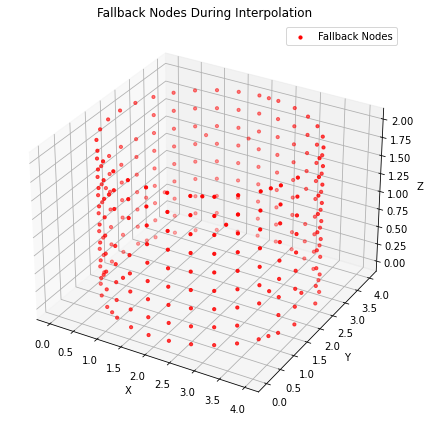


Fallback Nodes (x, y, z) and Radius from Center:
x = 0.4825, y = 3.3027, z = 2.0000, radius = 2.0000
x = 0.2513, y = 2.9706, z = 2.0000, radius = 2.0000
x = 0.0917, y = 2.5987, z = 2.0000, radius = 2.0000
x = 0.0103, y = 2.2023, z = 2.0000, radius = 2.0000
x = 0.0103, y = 1.7977, z = 2.0000, radius = 2.0000
x = 0.7758, y = 3.5816, z = 0.0000, radius = 2.0000
x = 0.4825, y = 3.3027, z = 0.0000, radius = 2.0000
x = 0.2513, y = 2.9706, z = 0.0000, radius = 2.0000
x = 0.0917, y = 2.5987, z = 0.0000, radius = 2.0000
x = 0.0103, y = 2.2023, z = 0.0000, radius = 2.0000
x = 0.0103, y = 1.7977, z = 0.0000, radius = 2.0000
x = 0.0103, y = 1.7977, z = 1.0000, radius = 2.0000
x = 0.0917, y = 2.5987, z = 1.0000, radius = 2.0000
x = 0.4825, y = 3.3027, z = 1.0000, radius = 2.0000
x = 0.7758, y = 3.5816, z = 1.0000, radius = 2.0000
x = 0.2513, y = 2.9706, z = 1.0000, radius = 2.0000
x = 0.0103, y = 2.2023, z = 1.0000, radius = 2.0000
x = 0.7758, y = 3.5816, z = 0.5000, radius = 2.0000
x = 0.0103, y 

In [30]:
import numpy as np
import h5py
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Load data ---
f_ref_0 = h5py.File('../Theis/Inputs_less_Q/ref_0/Theis.h5', 'r')
f_ref_neg_2 = h5py.File('../Theis/Inputs_less_Q/ref_neg_2/Theis.h5', 'r')

nodes_ref_0 = f_ref_0['nodesSpatial_Domain0'][:]
elements_ref_neg_2 = f_ref_neg_2['elementsSpatial_Domain0'][:]
nodes_ref_neg_2 = f_ref_neg_2['nodesSpatial_Domain0'][:]
psi_neg_2 = f_ref_neg_2['pressure_head_t100'][:]  # or any time

# --- Barycentric interpolation with fallback detection ---
def compute_barycentric_coords(p, tet_nodes):
    T = np.vstack((tet_nodes[1:] - tet_nodes[0])).T
    v = p - tet_nodes[0]
    try:
        lambdas = np.linalg.solve(T, v)
    except np.linalg.LinAlgError:
        return None
    l0 = 1 - np.sum(lambdas)
    return np.array([l0, *lambdas])

def interpolate_with_elements(source_nodes, source_elements, source_values, target_nodes):
    interpolated = np.full(len(target_nodes), np.nan)
    valid_mask = np.zeros(len(target_nodes), dtype=bool)
    tree = cKDTree(source_nodes)

    for i, pt in enumerate(target_nodes):
        _, near_inds = tree.query(pt, k=20)
        found = False
        for node_idx in near_inds:
            tet_indices = np.where(np.any(source_elements == node_idx, axis=1))[0]
            for tet_idx in tet_indices:
                tet = source_elements[tet_idx]
                tet_coords = source_nodes[tet]
                bary = compute_barycentric_coords(pt, tet_coords)
                if bary is None or np.any(bary < -1e-8):
                    continue
                interpolated[i] = np.dot(bary, source_values[tet])
                valid_mask[i] = True
                found = True
                break
            if found:
                break
    return interpolated, valid_mask

# --- Run interpolation ---
psi_interp, valid_mask = interpolate_with_elements(
    source_nodes=nodes_ref_neg_2,
    source_elements=elements_ref_neg_2,
    source_values=psi_neg_2,
    target_nodes=nodes_ref_0
)

# --- Extract fallback points ---
fallback_points = nodes_ref_0[~valid_mask]

# --- Plot fallback points in 3D ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(fallback_points[:, 0], fallback_points[:, 1], fallback_points[:, 2],
           c='red', s=10, label='Fallback Nodes')
ax.set_title('Fallback Nodes During Interpolation')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
plt.show()

# --- Define well center for radius calculation ---
center = (2.0, 2.0)

# --- Compute and print coordinates and radius ---
print("\nFallback Nodes (x, y, z) and Radius from Center:")
for pt in fallback_points:
    x, y, z = pt
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    print(f"x = {x:.4f}, y = {y:.4f}, z = {z:.4f}, radius = {r:.4f}")



In [10]:
import h5py
import numpy as np
from scipy.special import exp1
import xml.etree.ElementTree as ET

# --- Load data ---
f_ref_0 = h5py.File('../Theis/Inputs_less_Q/ref_0/Theis.h5', 'r')
elements = f_ref_0['elementsSpatial_Domain0'][:]
nodes = f_ref_0['nodesSpatial_Domain0'][:]
psi_0 = f_ref_0['pressure_head_t0'][:]

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

# --- Compute Voronoi volumes ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights = compute_voronoi_volumes(nodes, elements)

# --- Compute L2 error ---
def compute_L2_error(ph_num, ph_exact, weights):
    return (
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)),
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)) / 
        np.sqrt(np.sum(weights * (ph_exact)**2))
    )

# --- Theis head ---
def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

# --- Get time from XML ---
def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

# --- Loop over time steps ---
error_log_ref_0 = []

for key in f_ref_0:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_0:
            continue

        # Get time
        t_val = get_time_from_xml(f_ref_0[mesh_key][:])
        psi_num = f_ref_0[key][:]

        # Compute exact solution
        psi_exact = np.array([
            compute_theis_head(x, y, psi_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes)
        ])

        abs_l2, rel_l2 = compute_L2_error(psi_num, psi_exact, weights)
        error_log_ref_0.append((t_val, abs_l2, rel_l2))

# --- Sort by time ---
error_log_ref_0.sort(key=lambda x: x[0])

# --- Print all sorted results ---
for t_val, abs_l2, rel_l2 in error_log_ref_0:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e}")



C:\Users\12254\AppData\Local\Temp/ipykernel_19164/2294039499.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.50 s | Abs L2: 1.7618e-03 | Rel L2: 3.0523e-04
Time: 1.00 s | Abs L2: 2.7827e-03 | Rel L2: 4.8221e-04
Time: 1.50 s | Abs L2: 3.4400e-03 | Rel L2: 5.9626e-04
Time: 2.00 s | Abs L2: 4.1577e-03 | Rel L2: 7.2081e-04
Time: 2.50 s | Abs L2: 4.9405e-03 | Rel L2: 8.5666e-04
Time: 3.00 s | Abs L2: 5.5954e-03 | Rel L2: 9.7037e-04
Time: 3.50 s | Abs L2: 6.1701e-03 | Rel L2: 1.0702e-03
Time: 4.00 s | Abs L2: 6.6830e-03 | Rel L2: 1.1593e-03
Time: 4.50 s | Abs L2: 7.1475e-03 | Rel L2: 1.2400e-03
Time: 5.00 s | Abs L2: 7.5736e-03 | Rel L2: 1.3141e-03
Time: 5.50 s | Abs L2: 7.7513e-03 | Rel L2: 1.3450e-03
Time: 6.00 s | Abs L2: 7.8078e-03 | Rel L2: 1.3549e-03
Time: 6.50 s | Abs L2: 7.8048e-03 | Rel L2: 1.3545e-03
Time: 7.00 s | Abs L2: 7.7633e-03 | Rel L2: 1.3474e-03
Time: 7.50 s | Abs L2: 7.6969e-03 | Rel L2: 1.3360e-03
Time: 8.00 s | Abs L2: 7.6148e-03 | Rel L2: 1.3218e-03
Time: 8.50

In [12]:
import h5py
import numpy as np
from scipy.special import exp1
import xml.etree.ElementTree as ET

# --- Load data ---
f_ref_neg_2 = h5py.File('../Theis/Inputs_less_Q/ref_neg_2/Theis.h5', 'r')
elements = f_ref_neg_2['elementsSpatial_Domain0'][:]
nodes = f_ref_neg_2['nodesSpatial_Domain0'][:]
psi_0 = f_ref_neg_2['pressure_head_t0'][:]

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

# --- Compute Voronoi volumes ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights = compute_voronoi_volumes(nodes, elements)

# --- Compute L2 error ---
def compute_L2_error(ph_num, ph_exact, weights):
    return (
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)),
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)) / 
        np.sqrt(np.sum(weights * (ph_exact)**2))
    )

# --- Theis head ---
def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

# --- Get time from XML ---
def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

# --- Loop over time steps ---
error_log_ref_neg_2 = []

for key in f_ref_neg_2:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_2:
            continue

        # Get time
        t_val = get_time_from_xml(f_ref_neg_2[mesh_key][:])
        psi_num = f_ref_neg_2[key][:]

        # Compute exact solution
        psi_exact = np.array([
            compute_theis_head(x, y, psi_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes)
        ])

        abs_l2, rel_l2 = compute_L2_error(psi_num, psi_exact, weights)
        error_log_ref_neg_2.append((t_val, abs_l2, rel_l2))

# --- Sort by time ---
error_log_ref_neg_2.sort(key=lambda x: x[0])

# --- Print all sorted results ---
for t_val, abs_l2, rel_l2 in error_log_ref_neg_2:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e}")



C:\Users\12254\AppData\Local\Temp/ipykernel_19164/3586669872.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.50 s | Abs L2: 3.5982e-04 | Rel L2: 6.2138e-05
Time: 1.00 s | Abs L2: 1.9144e-04 | Rel L2: 3.3069e-05
Time: 1.50 s | Abs L2: 2.1763e-04 | Rel L2: 3.7602e-05
Time: 2.00 s | Abs L2: 7.9663e-04 | Rel L2: 1.3766e-04
Time: 2.50 s | Abs L2: 1.8926e-03 | Rel L2: 3.2711e-04
Time: 3.00 s | Abs L2: 2.4226e-03 | Rel L2: 4.1876e-04
Time: 3.50 s | Abs L2: 2.9242e-03 | Rel L2: 5.0551e-04
Time: 4.00 s | Abs L2: 3.3959e-03 | Rel L2: 5.8713e-04
Time: 4.50 s | Abs L2: 3.8238e-03 | Rel L2: 6.6117e-04
Time: 5.00 s | Abs L2: 4.2002e-03 | Rel L2: 7.2631e-04
Time: 5.50 s | Abs L2: 4.0041e-03 | Rel L2: 6.9246e-04
Time: 6.00 s | Abs L2: 3.7318e-03 | Rel L2: 6.4542e-04
Time: 6.50 s | Abs L2: 3.5052e-03 | Rel L2: 6.0626e-04
Time: 7.00 s | Abs L2: 3.3153e-03 | Rel L2: 5.7346e-04
Time: 7.50 s | Abs L2: 3.1557e-03 | Rel L2: 5.4589e-04
Time: 8.00 s | Abs L2: 3.0211e-03 | Rel L2: 5.2264e-04
Time: 8.50

In [8]:
error_log_ref_neg_1

[]

In [13]:
import h5py
import numpy as np
from scipy.special import exp1
import xml.etree.ElementTree as ET

# --- Load data ---
f_ref_neg_1 = h5py.File('../Theis/Inputs_less_Q/ref_neg_1/Theis.h5', 'r')
elements = f_ref_neg_1['elementsSpatial_Domain0'][:]
nodes = f_ref_neg_1['nodesSpatial_Domain0'][:]
psi_0 = f_ref_neg_1['pressure_head_t0'][:]

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

# --- Compute Voronoi volumes ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights = compute_voronoi_volumes(nodes, elements)

# --- Compute L2 error ---
def compute_L2_error(ph_num, ph_exact, weights):
    return (
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)),
        np.sqrt(np.sum(weights * (ph_num - ph_exact)**2)) / 
        np.sqrt(np.sum(weights * (ph_exact)**2))
    )

# --- Theis head ---
def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

# --- Get time from XML ---
def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

# --- Loop over time steps ---
error_log_ref_neg_1 = []

for key in f_ref_neg_1:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_1:
            continue

        # Get time
        t_val = get_time_from_xml(f_ref_neg_1[mesh_key][:])
        psi_num = f_ref_neg_1[key][:]

        # Compute exact solution
        psi_exact = np.array([
            compute_theis_head(x, y, psi_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes)
        ])

        abs_l2, rel_l2 = compute_L2_error(psi_num, psi_exact, weights)
        error_log_ref_neg_1.append((t_val, abs_l2, rel_l2))

# --- Sort by time ---
error_log_ref_neg_1.sort(key=lambda x: x[0])

# --- Print all sorted results ---
for t_val, abs_l2, rel_l2 in error_log_ref_neg_1:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e}")



C:\Users\12254\AppData\Local\Temp/ipykernel_19164/2759617642.py:42: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.00 s | Abs L2: 0.0000e+00 | Rel L2: 0.0000e+00
Time: 0.50 s | Abs L2: 1.8327e-03 | Rel L2: 3.1526e-04
Time: 1.00 s | Abs L2: 2.1616e-03 | Rel L2: 3.7194e-04
Time: 1.50 s | Abs L2: 2.2281e-03 | Rel L2: 3.8347e-04
Time: 2.00 s | Abs L2: 2.1439e-03 | Rel L2: 3.6906e-04
Time: 2.50 s | Abs L2: 2.3245e-03 | Rel L2: 4.0021e-04
Time: 3.00 s | Abs L2: 2.6153e-03 | Rel L2: 4.5033e-04
Time: 3.50 s | Abs L2: 2.9811e-03 | Rel L2: 5.1339e-04
Time: 4.00 s | Abs L2: 3.3682e-03 | Rel L2: 5.8014e-04
Time: 4.50 s | Abs L2: 3.7556e-03 | Rel L2: 6.4693e-04
Time: 5.00 s | Abs L2: 4.1304e-03 | Rel L2: 7.1156e-04
Time: 5.50 s | Abs L2: 4.0765e-03 | Rel L2: 7.0234e-04
Time: 6.00 s | Abs L2: 3.9100e-03 | Rel L2: 6.7370e-04
Time: 6.50 s | Abs L2: 3.7330e-03 | Rel L2: 6.4326e-04
Time: 7.00 s | Abs L2: 3.5603e-03 | Rel L2: 6.1353e-04
Time: 7.50 s | Abs L2: 3.3990e-03 | Rel L2: 5.8578e-04
Time: 8.00 s | Abs L2: 3.2521e-03 | Rel L2: 5.6051e-04
Time: 8.50

In [31]:
import h5py
import numpy as np
from scipy.special import exp1
from scipy.spatial import cKDTree
import xml.etree.ElementTree as ET

# --- Load both ref_0 and ref_neg_2 ---
f_ref_0 = h5py.File('../Theis/Inputs_less_Q/ref_0/Theis.h5', 'r')
f_ref_neg_1 = h5py.File('../Theis/Inputs_less_Q/ref_neg_1/Theis.h5', 'r')

nodes_ref_0 = f_ref_0['nodesSpatial_Domain0'][:]
elements_ref_0 = f_ref_0['elementsSpatial_Domain0'][:]
psi0_ref_0 = f_ref_0['pressure_head_t0'][:]

nodes_ref_neg_1 = f_ref_neg_1['nodesSpatial_Domain0'][:]
elements_ref_neg_1 = f_ref_neg_1['elementsSpatial_Domain0'][:]

# --- Compute Voronoi volumes (weights) on ref_0 mesh ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights_ref_0 = compute_voronoi_volumes(nodes_ref_0, elements_ref_0)

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

def compute_L2_error(ph_num, ph_exact, weights):
    diff_sq = (ph_num - ph_exact)**2
    exact_sq = ph_exact**2
    abs_l2 = np.sqrt(np.sum(weights * diff_sq))
    rel_l2 = abs_l2 / np.sqrt(np.sum(weights * exact_sq)) if np.sum(weights * exact_sq) > 0 else np.nan
    return abs_l2, rel_l2

# --- Barycentric interpolation using source elements ---
def compute_barycentric_coords(p, tet_nodes):
    T = np.vstack((tet_nodes[1:] - tet_nodes[0])).T
    v = p - tet_nodes[0]
    try:
        lambdas = np.linalg.solve(T, v)
    except np.linalg.LinAlgError:
        return None
    l0 = 1 - np.sum(lambdas)
    return np.array([l0, *lambdas])

def interpolate_with_elements(source_nodes, source_elements, source_values, target_nodes):
    interpolated = np.full(len(target_nodes), np.nan)
    valid_mask = np.zeros(len(target_nodes), dtype=bool)
    tree = cKDTree(source_nodes)
    fallback_count = 0

    for i, pt in enumerate(target_nodes):
        _, near_inds = tree.query(pt, k=20)
        found = False
        for node_idx in near_inds:
            tet_indices = np.where(np.any(source_elements == node_idx, axis=1))[0]
            for tet_idx in tet_indices:
                tet = source_elements[tet_idx]
                tet_coords = source_nodes[tet]
                bary = compute_barycentric_coords(pt, tet_coords)
                if bary is None or np.any(bary < -1e-8):
                    continue
                interpolated[i] = np.dot(bary, source_values[tet])
                valid_mask[i] = True
                found = True
                break
            if found:
                break
        if not found:
            interpolated[i] = 0.0
            fallback_count += 1

    return interpolated, fallback_count, valid_mask

# --- Loop over time steps ---
error_log_interp_neg_1_to_theis_ref_0 = []

for key in f_ref_neg_1:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_1:
            continue

        t_val = get_time_from_xml(f_ref_neg_1[mesh_key][:])
        psi_neg_1 = f_ref_neg_1[key][:]

        # Interpolate with fallback tracking
        psi_interp_on_ref_0, fallback_count, valid_mask = interpolate_with_elements(
            source_nodes=nodes_ref_neg_1,
            source_elements=elements_ref_neg_1,
            source_values=psi_neg_1,
            target_nodes=nodes_ref_0
        )

        # Compute Theis solution
        psi_theis_ref_0 = np.array([
            compute_theis_head(x, y, psi0_ref_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes_ref_0)
        ])

        # Mask out fallback nodes for error computation
        psi_interp_valid = psi_interp_on_ref_0[valid_mask]
        psi_theis_valid = psi_theis_ref_0[valid_mask]
        weights_valid = weights_ref_0[valid_mask]

        abs_l2, rel_l2 = compute_L2_error(psi_interp_valid, psi_theis_valid, weights_valid)
        error_log_interp_neg_1_to_theis_ref_0.append((t_val, abs_l2, rel_l2, fallback_count))

# --- Sort and print ---
error_log_interp_neg_1_to_theis_ref_0.sort(key=lambda x: x[0])
for t_val, abs_l2, rel_l2, fallback_count in error_log_interp_neg_1_to_theis_ref_0:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e} | Fallbacks: {fallback_count}/{len(nodes_ref_0)}")


C:\Users\12254\AppData\Local\Temp/ipykernel_19164/1105419226.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 4.1593e-16 | Rel L2: 7.7673e-17 | Fallbacks: 274/1348
Time: 0.00 s | Abs L2: 4.1593e-16 | Rel L2: 7.7673e-17 | Fallbacks: 274/1348
Time: 0.50 s | Abs L2: 1.9892e-03 | Rel L2: 3.7160e-04 | Fallbacks: 274/1348
Time: 1.00 s | Abs L2: 2.2373e-03 | Rel L2: 4.1806e-04 | Fallbacks: 274/1348
Time: 1.50 s | Abs L2: 2.2485e-03 | Rel L2: 4.2026e-04 | Fallbacks: 274/1348
Time: 2.00 s | Abs L2: 2.0295e-03 | Rel L2: 3.7940e-04 | Fallbacks: 274/1348
Time: 2.50 s | Abs L2: 1.8622e-03 | Rel L2: 3.4820e-04 | Fallbacks: 274/1348
Time: 3.00 s | Abs L2: 2.0093e-03 | Rel L2: 3.7576e-04 | Fallbacks: 274/1348
Time: 3.50 s | Abs L2: 2.2741e-03 | Rel L2: 4.2534e-04 | Fallbacks: 274/1348
Time: 4.00 s | Abs L2: 2.5855e-03 | Rel L2: 4.8365e-04 | Fallbacks: 274/1348
Time: 4.50 s | Abs L2: 2.9117e-03 | Rel L2: 5.4474e-04 | Fallbacks: 274/1348
Time: 5.00 s | Abs L2: 3.2353e-03 | Rel L2: 6.0533e-04 | Fallbacks: 274/1348
Time: 5.50 s | Abs L2: 3.2372e-03 | Rel L2: 6.0576e-04 | Fallbacks: 274/1348

In [28]:
import h5py
import numpy as np
from scipy.special import exp1
from scipy.spatial import cKDTree
import xml.etree.ElementTree as ET

# --- Load both ref_0 and ref_neg_2 ---
f_ref_0 = h5py.File('../Theis/Inputs_less_Q/ref_0/Theis.h5', 'r')
f_ref_neg_2 = h5py.File('../Theis/Inputs_less_Q/ref_neg_2/Theis.h5', 'r')

nodes_ref_0 = f_ref_0['nodesSpatial_Domain0'][:]
elements_ref_0 = f_ref_0['elementsSpatial_Domain0'][:]
psi0_ref_0 = f_ref_0['pressure_head_t0'][:]

nodes_ref_neg_2 = f_ref_neg_2['nodesSpatial_Domain0'][:]
elements_ref_neg_2 = f_ref_neg_2['elementsSpatial_Domain0'][:]

# --- Compute Voronoi volumes (weights) on ref_0 mesh ---
def compute_voronoi_volumes(nodes, elements):
    volumes = np.zeros(len(nodes))
    for tet in elements:
        tet_nodes = nodes[np.array(tet)]
        a, b, c, d = tet_nodes
        v = np.abs(np.dot((a - d), np.cross((b - d), (c - d)))) / 6.0
        for i in tet:
            volumes[i] += v / 4.0
    return volumes

weights_ref_0 = compute_voronoi_volumes(nodes_ref_0, elements_ref_0)

# --- Theis parameters ---
Q = 1e-5
T = 5e-4
S = 1e-3
center = (2.0, 2.0)

def compute_theis_head(x, y, psi0, t):
    r2 = (x - center[0])**2 + (y - center[1])**2
    u = (r2 * S) / (4.0 * T * t)
    return psi0 - (Q / (4.0 * np.pi * T)) * exp1(u)

def get_time_from_xml(xml_bytes):
    root = ET.fromstring(xml_bytes)
    return float(root.find('Time').attrib['Value'])

def compute_L2_error(ph_num, ph_exact, weights):
    diff_sq = (ph_num - ph_exact)**2
    exact_sq = ph_exact**2
    abs_l2 = np.sqrt(np.sum(weights * diff_sq))
    rel_l2 = abs_l2 / np.sqrt(np.sum(weights * exact_sq)) if np.sum(weights * exact_sq) > 0 else np.nan
    return abs_l2, rel_l2

# --- Barycentric interpolation using source elements ---
def compute_barycentric_coords(p, tet_nodes):
    T = np.vstack((tet_nodes[1:] - tet_nodes[0])).T
    v = p - tet_nodes[0]
    try:
        lambdas = np.linalg.solve(T, v)
    except np.linalg.LinAlgError:
        return None
    l0 = 1 - np.sum(lambdas)
    return np.array([l0, *lambdas])

def interpolate_with_elements(source_nodes, source_elements, source_values, target_nodes):
    interpolated = np.full(len(target_nodes), np.nan)
    valid_mask = np.zeros(len(target_nodes), dtype=bool)
    tree = cKDTree(source_nodes)
    fallback_count = 0

    for i, pt in enumerate(target_nodes):
        _, near_inds = tree.query(pt, k=20)
        found = False
        for node_idx in near_inds:
            tet_indices = np.where(np.any(source_elements == node_idx, axis=1))[0]
            for tet_idx in tet_indices:
                tet = source_elements[tet_idx]
                tet_coords = source_nodes[tet]
                bary = compute_barycentric_coords(pt, tet_coords)
                if bary is None or np.any(bary < -1e-8):
                    continue
                interpolated[i] = np.dot(bary, source_values[tet])
                valid_mask[i] = True
                found = True
                break
            if found:
                break
        if not found:
            interpolated[i] = 0.0
            fallback_count += 1

    return interpolated, fallback_count, valid_mask

# --- Loop over time steps ---
error_log_interp_neg_2_to_theis_ref_0 = []

for key in f_ref_neg_2:
    if key.startswith("pressure_head_t"):
        idx = key.replace("pressure_head_t", "")
        mesh_key = f"Mesh_Spatial_Domain_{idx}"
        if mesh_key not in f_ref_neg_2:
            continue

        t_val = get_time_from_xml(f_ref_neg_2[mesh_key][:])
        psi_neg_2 = f_ref_neg_2[key][:]

        # Interpolate with fallback tracking
        psi_interp_on_ref_0, fallback_count, valid_mask = interpolate_with_elements(
            source_nodes=nodes_ref_neg_2,
            source_elements=elements_ref_neg_2,
            source_values=psi_neg_2,
            target_nodes=nodes_ref_0
        )

        # Compute Theis solution
        psi_theis_ref_0 = np.array([
            compute_theis_head(x, y, psi0_ref_0[i], t_val)
            for i, (x, y, z) in enumerate(nodes_ref_0)
        ])

        # Mask out fallback nodes for error computation
        psi_interp_valid = psi_interp_on_ref_0[valid_mask]
        psi_theis_valid = psi_theis_ref_0[valid_mask]
        weights_valid = weights_ref_0[valid_mask]

        abs_l2, rel_l2 = compute_L2_error(psi_interp_valid, psi_theis_valid, weights_valid)
        error_log_interp_neg_2_to_theis_ref_0.append((t_val, abs_l2, rel_l2, fallback_count))

# --- Sort and print ---
error_log_interp_neg_2_to_theis_ref_0.sort(key=lambda x: x[0])
for t_val, abs_l2, rel_l2, fallback_count in error_log_interp_neg_2_to_theis_ref_0:
    print(f"Time: {t_val:.2f} s | Abs L2: {abs_l2:.4e} | Rel L2: {rel_l2:.4e} | Fallbacks: {fallback_count}/{len(nodes_ref_0)}")


C:\Users\12254\AppData\Local\Temp/ipykernel_19164/1229900097.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  u = (r2 * S) / (4.0 * T * t)


Time: 0.00 s | Abs L2: 4.5023e-16 | Rel L2: 8.4223e-17 | Fallbacks: 277/1348
Time: 0.00 s | Abs L2: 4.5023e-16 | Rel L2: 8.4223e-17 | Fallbacks: 277/1348
Time: 0.50 s | Abs L2: 6.0788e-03 | Rel L2: 1.1375e-03 | Fallbacks: 277/1348
Time: 1.00 s | Abs L2: 6.3758e-03 | Rel L2: 1.1934e-03 | Fallbacks: 277/1348
Time: 1.50 s | Abs L2: 6.2559e-03 | Rel L2: 1.1713e-03 | Fallbacks: 277/1348
Time: 2.00 s | Abs L2: 5.9091e-03 | Rel L2: 1.1066e-03 | Fallbacks: 277/1348
Time: 2.50 s | Abs L2: 5.1581e-03 | Rel L2: 9.6613e-04 | Fallbacks: 277/1348
Time: 3.00 s | Abs L2: 4.8691e-03 | Rel L2: 9.1215e-04 | Fallbacks: 277/1348
Time: 3.50 s | Abs L2: 4.6366e-03 | Rel L2: 8.6872e-04 | Fallbacks: 277/1348
Time: 4.00 s | Abs L2: 4.4564e-03 | Rel L2: 8.3507e-04 | Fallbacks: 277/1348
Time: 4.50 s | Abs L2: 4.3264e-03 | Rel L2: 8.1081e-04 | Fallbacks: 277/1348
Time: 5.00 s | Abs L2: 4.2428e-03 | Rel L2: 7.9521e-04 | Fallbacks: 277/1348
Time: 5.50 s | Abs L2: 4.2548e-03 | Rel L2: 7.9754e-04 | Fallbacks: 277/1348

In [21]:
import numpy as np

# All error logs
error_logs = {
    #'ref_neg_2': error_log_ref_neg_2,
    #'ref_neg_1': error_log_ref_neg_1,
    'ref_0':     error_log_ref_0,
    'ref_1':     error_log_ref_1,
    #'ref_2':     error_log
}

# Corresponding mesh sizes (replace with real ones if known)
mesh_sizes = {
    #'ref_neg_2': 0.4,
    #'ref_neg_1': 0.2,
    'ref_0':     0.1,
    'ref_1':     0.05,
    #'ref_2':     0.025
}

# Get all unique time steps
all_times = sorted(set(round(t, 5) for log in error_logs.values() for t, _, _ in log))
time_tol = 1e-5

# Build a dictionary: time → list of (h, rel_L2)
from collections import defaultdict
time_to_errors = defaultdict(list)

for name, log in error_logs.items():
    h = mesh_sizes[name]
    for t, abs_l2, rel_l2 in log:
        t_rounded = round(t, 5)
        time_to_errors[t_rounded].append((h, rel_l2))

# Compute convergence rates at each time
for t in sorted(time_to_errors.keys()):
    data = sorted(time_to_errors[t], key=lambda x: x[0])  # sort by h
    if len(data) < 2:
        continue  # need at least 2 levels to compute rate
    #print(f"\nTime = {t:.2f} s")
    for i in range(len(data) - 1):
        h1, e1 = data[i]
        h2, e2 = data[i + 1]
        if e2 == 0 or e1 == 0:
            rate = np.nan
        else:
            rate = np.log(e1 / e2) / np.log(h1 / h2)
        #print(f"  h = {h1:.4f} → {h2:.4f} | Rel L2: {e1:.2e} → {e2:.2e} | Rate ≈ {rate:.2f}")
        print(f"Time = {t:.2f} s", f" Rate ≈ {rate:.2f}")


Time = 0.00 s  Rate ≈ nan
Time = 0.00 s  Rate ≈ nan
Time = 0.00 s  Rate ≈ nan
Time = 0.50 s  Rate ≈ 0.06
Time = 1.00 s  Rate ≈ -0.09
Time = 1.50 s  Rate ≈ -0.15
Time = 2.00 s  Rate ≈ -0.20
Time = 2.50 s  Rate ≈ -0.18
Time = 3.00 s  Rate ≈ -0.17
Time = 3.50 s  Rate ≈ -0.16
Time = 4.00 s  Rate ≈ -0.15
Time = 4.50 s  Rate ≈ -0.15
Time = 5.00 s  Rate ≈ -0.14
Time = 5.50 s  Rate ≈ -0.14
Time = 6.00 s  Rate ≈ -0.16
Time = 6.50 s  Rate ≈ -0.18
Time = 7.00 s  Rate ≈ -0.19
Time = 7.50 s  Rate ≈ -0.21
Time = 8.00 s  Rate ≈ -0.22
Time = 8.50 s  Rate ≈ -0.24
Time = 9.00 s  Rate ≈ -0.25
Time = 9.50 s  Rate ≈ -0.25
Time = 10.00 s  Rate ≈ -0.26
Time = 10.50 s  Rate ≈ -0.26
Time = 11.00 s  Rate ≈ -0.26
Time = 11.50 s  Rate ≈ -0.26
Time = 12.00 s  Rate ≈ -0.26
Time = 12.50 s  Rate ≈ -0.25
Time = 13.00 s  Rate ≈ -0.24
Time = 13.50 s  Rate ≈ -0.23
Time = 14.00 s  Rate ≈ -0.22
Time = 14.50 s  Rate ≈ -0.21
Time = 15.00 s  Rate ≈ -0.19
Time = 15.50 s  Rate ≈ -0.18
Time = 16.00 s  Rate ≈ -0.16
Time = 16.50 s

In [22]:
import numpy as np

# All error logs
error_logs = {
    'ref_neg_2': error_log_ref_neg_2,
    'ref_neg_1': error_log_ref_neg_1,
    #'ref_0':     error_log_ref_0,
    #'ref_1':     error_log_ref_1,
    #'ref_2':     error_log
}

# Corresponding mesh sizes (replace with real ones if known)
mesh_sizes = {
    'ref_neg_2': 0.4,
    'ref_neg_1': 0.2,
    #'ref_0':     0.1,
    #'ref_1':     0.05,
    #'ref_2':     0.025
}

# Get all unique time steps
all_times = sorted(set(round(t, 5) for log in error_logs.values() for t, _, _ in log))
time_tol = 1e-5

# Build a dictionary: time → list of (h, rel_L2)
from collections import defaultdict
time_to_errors = defaultdict(list)

for name, log in error_logs.items():
    h = mesh_sizes[name]
    for t, abs_l2, rel_l2 in log:
        t_rounded = round(t, 5)
        time_to_errors[t_rounded].append((h, rel_l2))

# Compute convergence rates at each time
for t in sorted(time_to_errors.keys()):
    data = sorted(time_to_errors[t], key=lambda x: x[0])  # sort by h
    if len(data) < 2:
        continue  # need at least 2 levels to compute rate
    #print(f"\nTime = {t:.2f} s")
    for i in range(len(data) - 1):
        h1, e1 = data[i]
        h2, e2 = data[i + 1]
        if e2 == 0 or e1 == 0:
            rate = np.nan
        else:
            rate = np.log(e1 / e2) / np.log(h1 / h2)
        #print(f"  h = {h1:.4f} → {h2:.4f} | Rel L2: {e1:.2e} → {e2:.2e} | Rate ≈ {rate:.2f}")
        print(f"Time = {t:.2f} s", f" Rate ≈ {rate:.2f}")


Time = 0.00 s  Rate ≈ nan
Time = 0.00 s  Rate ≈ nan
Time = 0.00 s  Rate ≈ nan
Time = 0.50 s  Rate ≈ -2.34
Time = 1.00 s  Rate ≈ -3.49
Time = 1.50 s  Rate ≈ -3.35
Time = 2.00 s  Rate ≈ -1.42
Time = 2.50 s  Rate ≈ -0.29
Time = 3.00 s  Rate ≈ -0.10
Time = 3.50 s  Rate ≈ -0.02
Time = 4.00 s  Rate ≈ 0.02
Time = 4.50 s  Rate ≈ 0.03
Time = 5.00 s  Rate ≈ 0.03
Time = 5.50 s  Rate ≈ -0.02
Time = 6.00 s  Rate ≈ -0.06
Time = 6.50 s  Rate ≈ -0.09
Time = 7.00 s  Rate ≈ -0.10
Time = 7.50 s  Rate ≈ -0.10
Time = 8.00 s  Rate ≈ -0.10
Time = 8.50 s  Rate ≈ -0.10
Time = 9.00 s  Rate ≈ -0.09
Time = 9.50 s  Rate ≈ -0.08
Time = 10.00 s  Rate ≈ -0.07
Time = 10.50 s  Rate ≈ -0.06
Time = 11.00 s  Rate ≈ -0.05
Time = 11.50 s  Rate ≈ -0.04
Time = 12.00 s  Rate ≈ -0.02
Time = 12.50 s  Rate ≈ -0.01
Time = 13.00 s  Rate ≈ 0.00
Time = 13.50 s  Rate ≈ 0.02
Time = 14.00 s  Rate ≈ 0.03
Time = 14.50 s  Rate ≈ 0.05
Time = 15.00 s  Rate ≈ 0.06
Time = 15.50 s  Rate ≈ 0.08
Time = 16.00 s  Rate ≈ 0.09
Time = 16.50 s  Rate ≈ 